## Example of calibration for simple time series model
Based on "Sequentially valid tests for forecast calibration"  
By: 
Sebastian Arnold
Alexander Henzi
Johanna F. Ziegel

Background:

Econometric forecasts are typically presented as point estimates $\hat{y}_{t+h}$ and evaluated using loss functions like $L(y_{t+h},\hat{y}_{t+h})$, for example mean squared error (MSE). However, each prediction represents a parameter of the underlying distribution, not just a single value. For example, in an AR(1) model with normal errors, the forecast describes the conditional mean where $y_t|y_{t-1} \sim \mathcal{N}(\theta y_{t-1},\sigma^2)$. Probabilistic forecasts incorporate uncertainty about $\hat{y}_{t+h}$ through forecasting a probability distributions rather than point estimates alone.

This notebook extents the notion of loss functions $L(y_{t+h},\hat{y}_{t+h})$ to probabilistic forecast. The concept of checking whether probalistic forecast are "good" is what is know as calibration.

In [ ]:
#%load_ext autoreload
#%autoreload 2
import numpy as np
import pandas as pd
from scipy.stats import norm
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Consider a true data generating process to be an AR(1), it can for instance represent a true change in sales, denoted as $(y_t)_{t\in\mathbb{N}}$. Additionally, assume that stationary conditions hold. For each simulated value, the true process is given by:
\begin{equation*}
    Y:=y_t|y_{t-1} \sim \mathcal{N}(\theta y_{t-1},\sigma^2).
\end{equation*}
where $\theta$ is the true parameters that describes the true relationship between $y_t$ and $y_{t-1}$. In practice $\theta$ is unknown and must be estimated by historical data yielding the fitted distribution:
\begin{equation*}
    F := y_t|y_{t-1} \sim \mathcal{N}(\hat{\theta}y_{t-1},\sigma^2).
\end{equation*}
Now to illustrate the effect of miscalibrated forecast consider that the fitted/forecasted distribution $F$ is transformed according to $F = \mathcal{N}(\hat{\theta}y_{t-1} + \epsilon,(\sigma+ \delta)^2)$, where $\epsilon,\delta \in \{-0.5,-0.3, \cdots, 0.5\}$ are the bias and dispersion, respectively and $\hat{\theta}$ the maximum likelihood estimator. This transformation would result in probabilistic forecasts being misaligned with the true data process. Only for the case of $\epsilon=\delta=0$ and $\hat{\theta} = \theta$ are the probabilistic forecast perfectly calibrated.


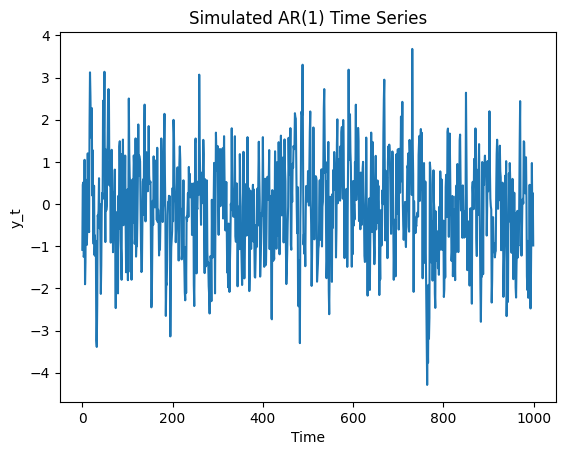

In [6]:
# --- Example 1: Simulate an AR(1) time series ---
np.random.seed(123)
n = 1000

# --- Generate AR(1) series y_t = 0.5 y_{t-1} + eps_t ---
sd0 = 1
eps = np.random.normal(0, sd0, n)

y = np.zeros(n)
y[0] = eps[0]
for t in range(1, n):
    y[t] = 0.5 * y[t - 1] + eps[t]

plt.plot(np.arange(n), y)
plt.title("Simulated AR(1) Time Series")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.show()


In [7]:
# --- Construct lagged dataframe ---
Y_true = pd.DataFrame({
    "y": y[1:],          # current value
    "y1": y[:-1]         # lag 1
})

# --- OLS: y ~ y1 - 1 (no intercept) ---
model = sm.OLS(Y_true["y"], Y_true["y1"])
results = model.fit()
Y_fitted = results.fittedvalues.values

# --- Bias & dispersion grid --- 
# This is induced distance between the true parameter value and the estimated one. 
# Where bias is the error in the mean estimate, dispersion is the error in the variance estimate.
# Note  that for a AR(1) process the dispersion is not estimated.
bias_vals = [-0.5, -0.3, -0.1, 0, 0.1, 0.3, 0.5]
disp_vals = [-0.5, -0.3, -0.1, 0, 0.1, 0.3, 0.5]

bias_disp = pd.DataFrame(
    [(b, d) for b in bias_vals for d in disp_vals],
    columns=["bias", "dispersion"]
)

# Maximimun likelihood estimation of theta parameter
model.fit().params

NameError: name 'sm' is not defined

---
Testing for misalignment can be done by the use of the Probability Integral transform theorem. Recall (theorem 2.1.10 in Casella and Berger), a simple proof of this theorem can also be found in Casella and Berger ~p.55.

*Theorem* : Let $X$ have continuous cdf $F_X(x)$ and define the random variable $Y = F_X(X)$. Then $Y$ is uniformly distributed on (0, 1), that is, $P(Y ≤ y) = y$.  

Translating this theorem to the AR(1) example one would obtain the following expression. The probability integral transform of a forecast $F$ for a random variable $Y$ is defined by:
\begin{equation*}
    Z_{F(\theta,\sigma^2)}(Y) = F(Y). 
\end{equation*}
The forecast $F$ is probabilistically well calibrated if $Z_F(Y)~\sim \mathcal{U}(0,1)$, where realization of this distribution are referred to as pit values $(z_t)_{t\in\mathbb{N}}$. One can now construct a hypothesis test for testing whether a probabilistic forecast $F$ is calibrated by considering:

\begin{equation*}
    \mathcal{H}_0: Z_{F}(Y) \sim \mathcal{U}(0,1) \quad vs \quad \mathcal{H}_1: Z_F(Y) \in \mathcal{D}([0,1])
\end{equation*}
where $\mathcal{D}([0,1])$ is the family of valid distributions on $[0,1]$ excluding the uniform distribution. 

Rather then going directly to constructing parametric and non-parametric test we continue to illustrate the effect of miscalibrated forecast with $F = \mathcal{N}(\hat{\theta}y_{t-1} + \epsilon,(\sigma+ \delta)^2)$.




In [ ]:
# --- Compute PIT values ---
rows = []
for _, row in bias_disp.iterrows():
    eps = row["bias"]
    delta = row["dispersion"]
    
    # Apply the probability integral transform (PIT)
    # Note that norm.cdf is the cdf of the probabilistic forecast F.
    # Hence the following line computes Z_F(Y) with F = N(Y_fitted + eps, (1 + delta)^2)
    pit = norm.cdf(
        Y_true["y"], 
        loc=Y_fitted + eps, # Y_fitted := theta_hat * y_{t-1}
        scale=np.sqrt(1 + delta) # Note that in norm.cdf scale is stddev not variance
    )
    
    df_tmp = pd.DataFrame({
        "bias": eps,
        "dispersion": delta,
        "pit": pit
    })
    rows.append(df_tmp)

hist_dat = pd.concat(rows, ignore_index=True)


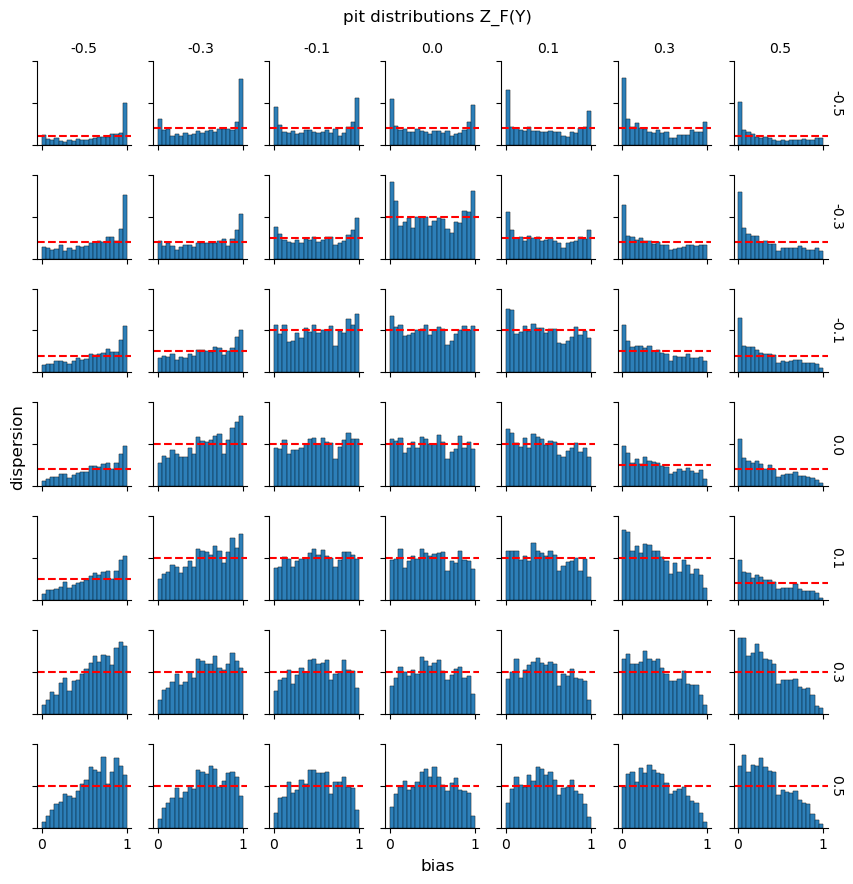

In [ ]:
g = sns.FacetGrid(
    hist_dat, 
    row="dispersion", 
    col="bias", 
    sharey=False,
    margin_titles=True,
    height=1.2
)

g.map_dataframe(
    sns.histplot, 
    x="pit", 
    stat="density", 
    binwidth=0.05, 
   binrange=(0,1)
)

g.map_dataframe(
    sns.histplot, 
    x="pit", 
    stat="density", 
    binwidth=0.05, 
    binrange=(0,1)
)
g.refline(y=1, color="red", linestyle="--")
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.set_axis_labels("", "")
g.set_yticklabels([])
g.tight_layout()
g.figure.text(0.5,0, "bias", ha="center", va="center", fontsize=12)
g.figure.text(0, 0.5, "dispersion", ha="center", va="center", rotation="vertical", fontsize=12)
g.figure.suptitle(t=r"pit distributions Z_F(Y)", y= 1.02, fontsize=12)
plt.show()

It becomes clear from this example that if the probabilistic forecast is misaligned the corresponding distribution $Z_F(Y)$ will diverge from following a standard uniform distribution. 

## Using e-values to test miscalibration
Under development: here will come an example of both the parametric and non-parametric setting 

## parametric setting
BETA: estimation: both sequential and non sequential
Checking whether the z values are between the correct bound of the uniform distribution

In [ ]:
from expectation.seqtest.sequential_e_testing import SequentialTesting
from expectation.seqcalibration.sequential_calibration import beta_e
from scipy.stats import beta

In [ ]:
pit_values = np.random.beta(a=2, b=5, size=50)
pit_test = beta_e(pit_values,n0=20)
print(pit_test)

beta_e summary:
Number of PIT values: 50
n0 (min obs for estimation): 20
Latest estimated a, b: [2. 5.]
PIT min: 0.0305, PIT max: 0.7978, PIT mean: 0.3029
e-values: [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.83277211 0.99991652 1.09766596 1.44993618
 1.44364338 0.92298926 2.05198465 0.83104299 1.96558712 1.4302564
 2.08533873 1.3785133  1.7115904  1.59722033 0.67099401 0.64418352
 0.62383166 1.96398576 1.32667738 2.03782772 2.10913819 2.10033551
 0.56580433 2.10623042 1.79085596 2.08444063 2.1061704  1.90202517
 1.47012657 2.43123112]



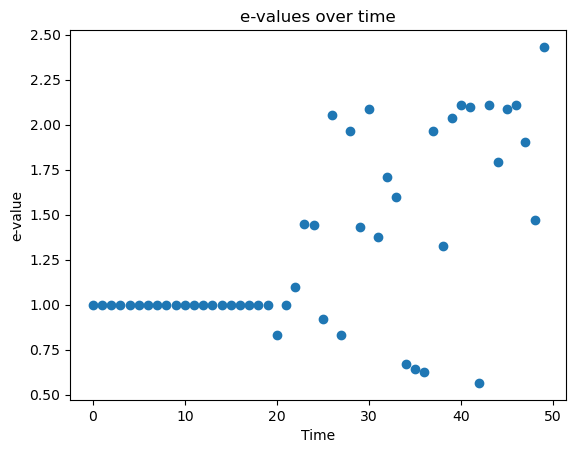

In [ ]:
plt.scatter(range(0,pit_test.n), pit_test.e_values)
plt.title("e-values over time")
plt.xlabel("Time")
plt.ylabel("e-value")
plt.show()

## Example of misscalibration ar(p)-garch(p,q) models

In [ ]:
# --- Example 2: Simulate an AR(1)-GARCH(1,1) time series ---
np.random.seed(123)
from arch import arch_model
# --- Define parameters ---

mu     = 0.5     # constant in the mean model
phi    = 0.7     # AR(1) coefficient in the mean model
omega  = 0.1     # GARCH constant in the variance model
alpha  = 0.15    # ARCH(1) coefficient in the variance model
beta1   = 0.8     # GARCH(1) coefficient in the variance model

T = 500  # number of observations

# --- Specify AR(1)-GARCH(1,1) model ---
am = arch_model(
    y =None,
    mean='AR', lags=1,
    vol='GARCH', p=1, q=1,
    dist='normal'
)

# Order of parameters expected:
# [mu, ar.L1, omega, alpha[1], beta1[1]]
params = np.array([mu, phi, omega, alpha, beta1])

# --- Simulate ---
sim = am.simulate(params, nobs=T, burn=500)

# Extract the series
Y = sim['data']
sim.head()

,data,volatility,errors
0,1.153053,1.129523,-0.596828
1,2.197587,1.083553,0.890450
2,1.644025,1.076200,-0.394286
3,2.759077,1.024638,1.108259
4,2.497751,1.060256,0.066397


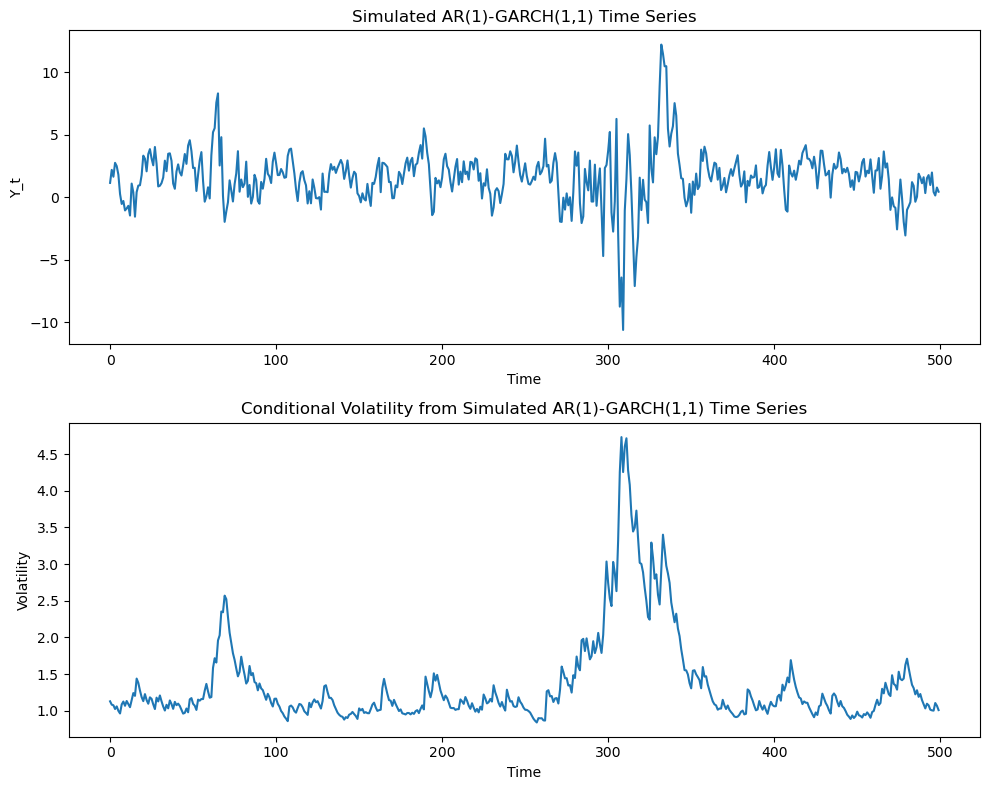

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Simulated AR(1)-GARCH(1,1) series mean equation
axes[0].plot(np.arange(T), Y)
axes[0].set_title("Simulated AR(1)-GARCH(1,1) Time Series")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Y_t")

# Plot 2: Conditional volatility; variance equation
axes[1].plot(np.arange(T), sim['volatility'])
axes[1].set_title("Conditional Volatility from Simulated AR(1)-GARCH(1,1) Time Series")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Volatility")

plt.tight_layout()
plt.show()


In [13]:
# --- Estimate ar(1)-garch(1,1) model and plot the fitted values---
mod = arch_model(y=sim['data'],mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal')
model1 = mod.fit(disp='off')
mean_model = model1.model.y - model1.resid # equals bias between fitted and observed values
std_model = model1.conditional_volatility # equals dispersion between fitted and observed values
model1

                           AR - GARCH Model Results                           
Dep. Variable:                   data   R-squared:                       0.474
Mean Model:                        AR   Adj. R-squared:                  0.473
Vol Model:                      GARCH   Log-Likelihood:               -817.019
Distribution:                  Normal   AIC:                           1644.04
Method:            Maximum Likelihood   BIC:                           1665.10
                                        No. Observations:                  499
Date:                Fri, Nov 28 2025   Df Residuals:                      497
Time:                        12:40:40   Df Model:                            2
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
Const          0.5766  7.753e-02      7.437  1.032e-13 [  0.425,  0.72

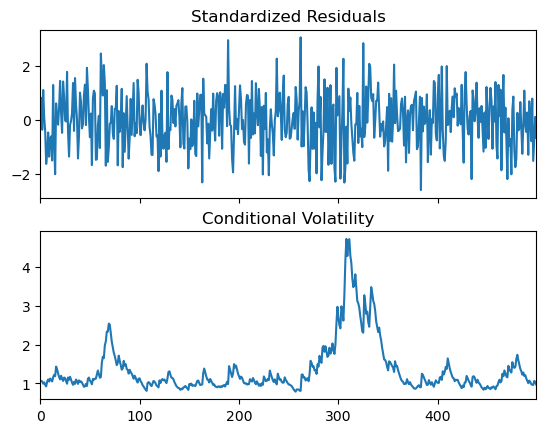

In [14]:
# --- plot the fitted model ---
model1.plot()
plt.show()


In [15]:
z = norm.cdf(Y ,loc=mean_model, scale=std_model)
pit_test = beta_e(z[1:],n0=10)
print(pit_test)

beta_e summary:
Number of PIT values: 499
n0 (min obs for estimation): 10
Latest estimated a, b: [0.001 1.   ]
PIT min: 0.0046, PIT max: 0.9989, PIT mean: 0.4992
e-values: [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 0.00111017 0.00439739 0.04550107 0.00137426 0.00190463 0.00234218
 0.00146418 0.00108163 0.00166868 0.00318273 0.00108531 0.00124203
 0.00203996 0.0021114  1.         0.00316956 0.01154996 0.00236372
 0.00206899 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.01695343 0.00329912 0.04614284 0.00641151 0.01168656
 0.00420654 0.00894881 0.00389175 0.00203039 0.00200959 0.0023449
 0.00232037 0.00274149 0.00221848 0.00221983 0.0053183  0.01139966
 0.00213202 0.

In [16]:
# Compute PIT values
z = norm.cdf(Y ,loc=mean_model, scale=std_model)
pit_test = beta_e(z[1:],n0=10)
print(pit_test)
pit_test.sequential_params[1:10]

beta_e summary:
Number of PIT values: 499
n0 (min obs for estimation): 10
Latest estimated a, b: [0.001 1.   ]
PIT min: 0.0046, PIT max: 0.9989, PIT mean: 0.4992
e-values: [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 0.00111017 0.00439739 0.04550107 0.00137426 0.00190463 0.00234218
 0.00146418 0.00108163 0.00166868 0.00318273 0.00108531 0.00124203
 0.00203996 0.0021114  1.         0.00316956 0.01154996 0.00236372
 0.00206899 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.01695343 0.00329912 0.04614284 0.00641151 0.01168656
 0.00420654 0.00894881 0.00389175 0.00203039 0.00200959 0.0023449
 0.00232037 0.00274149 0.00221848 0.00221983 0.0053183  0.01139966
 0.00213202 0.

array([[1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.]])

In [ ]:
%connect_info

{"key":"7f14d77a-f6c0-4d3a-a5ba-621165eb76d0","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9000,"control_port":9001,"shell_port":9002,"stdin_port":9003,"iopub_port":9004,"kernel_name":"python3135jvsc74a57bd00953f245535e648290a157bdb2dec951a68190e022dc07616a18cea35ff372f5"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing c:\Users\laure\AppData\Roaming\jupyter\runtime\kernel-v311b7745e90be354f4d9600ca2aeb70cd4c46dd07.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


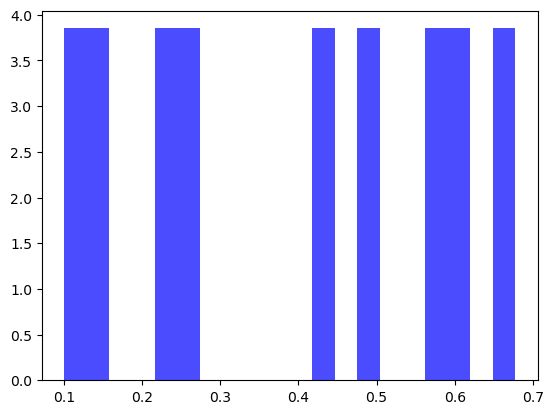

In [ ]:
# --- plot PIT histogram ---    
plt.hist(z[:10], bins=20, density=True, alpha=0.7, color='blue')
plt.show()


In [ ]:

beta.fit(z[1:10], floc=0, fscale=1)


(np.float64(2.1702192931968525), np.float64(3.4109726414995283), 0, 1)